In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "data/processed/iot_telemetry_features.csv"
)

print("Shape:", df.shape)
df.head()

Shape: (1785, 35)


,container_id,timestamp,commodity,temperature,humidity,vibration,condition,date,hour,day_of_week,...,max_vibration,warning_count,anomaly_count,avg_environmental_risk,commodity_avg_temperature,commodity_avg_humidity,commodity_avg_vibration,commodity_warning_count,commodity_anomaly_count,commodity_avg_risk
0,CONT_001,2026-09-10 17:39:32.831215,Avocado,3.94,71.79,0.29,WARNING,2026-09-10,17,3,...,0.59,62,36,2.894118,9.129163,88.956719,0.194729,71,53,2.952489
1,CONT_004,2026-09-10 17:39:34.852445,Mango,11.72,88.98,0.12,NORMAL,2026-09-10,17,3,...,0.59,81,36,2.942149,11.575468,86.437340,0.193234,97,51,2.689362
2,CONT_005,2026-09-10 17:39:36.870612,Tomato,10.18,91.05,0.15,NORMAL,2026-09-10,17,3,...,0.59,62,40,2.818182,10.869107,87.423878,0.184183,88,39,2.821351
3,CONT_005,2026-09-10 17:39:38.890192,Avocado,6.54,85.30,0.17,NORMAL,2026-09-10,17,3,...,0.59,62,40,2.818182,9.129163,88.956719,0.194729,71,53,2.952489
4,CONT_005,2026-09-10 17:39:40.899424,Tomato,14.06,100.00,0.33,WARNING,2026-09-10,17,3,...,0.59,62,40,2.818182,10.869107,87.423878,0.184183,88,39,2.821351


In [3]:
import os
print(os.getcwd())

C:\Users\PRITWISH\OneDrive\AtmoSync


In [4]:
print("Condition Distribution:")
print(df["condition"].value_counts())

print("\nSpoilage Risk Distribution:")
print(df["spoilage_risk"].value_counts())

print("\nEnvironmental Risk Distribution:")
print(df["environmental_risk"].value_counts())

print("\nAverage Environmental Risk:")
print(round(df["environmental_risk_score"].mean(), 2))

Condition Distribution:
condition
NORMAL     1249
WARNING     352
ANOMALY     184
Name: count, dtype: int64

Spoilage Risk Distribution:
spoilage_risk
LOW         890
MEDIUM      638
HIGH        222
CRITICAL     35
Name: count, dtype: int64

Environmental Risk Distribution:
environmental_risk
LOW         890
MEDIUM      638
HIGH        222
CRITICAL     35
Name: count, dtype: int64

Average Environmental Risk:
2.9


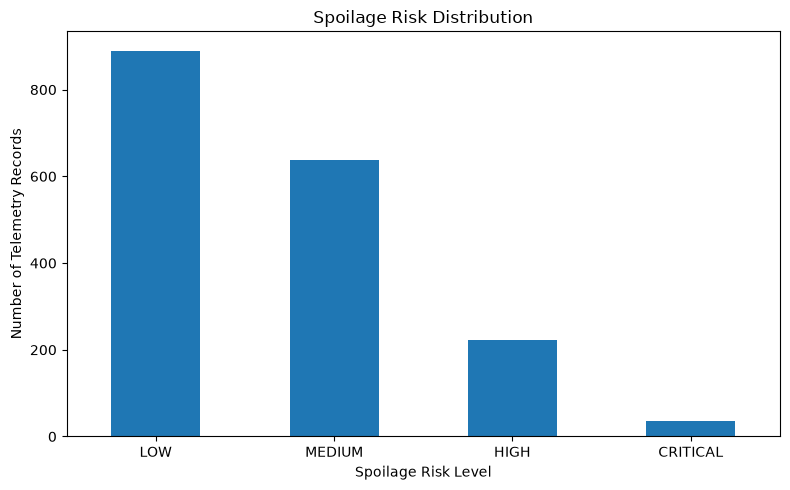

In [5]:
risk_counts = df["spoilage_risk"].value_counts()

plt.figure(figsize=(8, 5))

risk_counts.plot(kind="bar")

plt.title("Spoilage Risk Distribution")
plt.xlabel("Spoilage Risk Level")
plt.ylabel("Number of Telemetry Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [6]:
container_summary = (
    df.groupby("container_id")
    .agg(
        total_records=("container_id", "count"),
        warning_count=("condition", lambda x: (x == "WARNING").sum()),
        anomaly_count=("condition", lambda x: (x == "ANOMALY").sum()),
        high_risk_count=("spoilage_risk", lambda x: (x == "HIGH").sum()),
        critical_count=("spoilage_risk", lambda x: (x == "CRITICAL").sum()),
        avg_temperature=("temperature", "mean"),
        avg_humidity=("humidity", "mean"),
        avg_vibration=("vibration", "mean"),
        avg_environmental_risk=("environmental_risk_score", "mean"),
        max_environmental_risk=("environmental_risk_score", "max")
    )
    .reset_index()
)

container_summary

,container_id,total_records,warning_count,anomaly_count,high_risk_count,critical_count,avg_temperature,avg_humidity,avg_vibration,avg_environmental_risk,max_environmental_risk
0,CONT_001,340,62,36,38,8,11.294000,87.601118,0.192265,2.894118,8
1,CONT_002,339,65,35,43,8,11.068997,88.139204,0.188053,2.899705,7
2,CONT_003,369,82,37,52,8,11.193442,87.769675,0.196911,2.934959,7
3,CONT_004,363,81,36,51,5,11.374931,87.652039,0.190799,2.942149,7
4,CONT_005,374,62,40,38,6,11.204626,87.443556,0.187941,2.818182,7


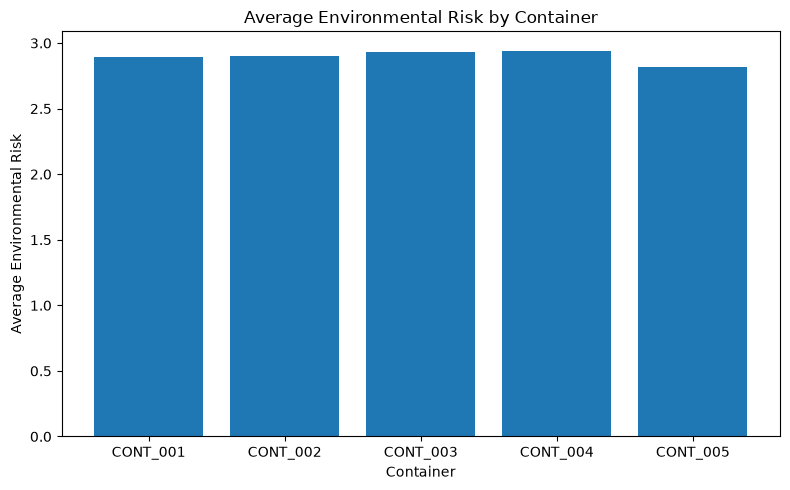

In [7]:
plt.figure(figsize=(8, 5))

plt.bar(
    container_summary["container_id"],
    container_summary["avg_environmental_risk"]
)

plt.title("Average Environmental Risk by Container")
plt.xlabel("Container")
plt.ylabel("Average Environmental Risk")

plt.tight_layout()
plt.show()

In [8]:
commodity_summary = (
    df.groupby("commodity")
    .agg(
        total_records=("commodity", "count"),
        warning_count=("condition", lambda x: (x == "WARNING").sum()),
        anomaly_count=("condition", lambda x: (x == "ANOMALY").sum()),
        high_risk_count=("spoilage_risk", lambda x: (x == "HIGH").sum()),
        critical_count=("spoilage_risk", lambda x: (x == "CRITICAL").sum()),
        avg_temperature=("temperature", "mean"),
        avg_humidity=("humidity", "mean"),
        avg_vibration=("vibration", "mean"),
        avg_environmental_risk=("environmental_risk_score", "mean")
    )
    .reset_index()
)

commodity_summary


,commodity,total_records,warning_count,anomaly_count,high_risk_count,critical_count,avg_temperature,avg_humidity,avg_vibration,avg_environmental_risk
0,Avocado,442,71,53,41,14,9.129163,88.956719,0.194729,2.952489
1,Banana,414,96,41,67,6,13.473140,88.164686,0.192995,3.159420
2,Mango,470,97,51,68,9,11.575468,86.437340,0.193234,2.689362
3,Tomato,459,88,39,46,6,10.869107,87.423878,0.184183,2.821351


In [9]:
commodity_summary.sort_values(
    "avg_environmental_risk",
    ascending=False
)

,commodity,total_records,warning_count,anomaly_count,high_risk_count,critical_count,avg_temperature,avg_humidity,avg_vibration,avg_environmental_risk
1,Banana,414,96,41,67,6,13.473140,88.164686,0.192995,3.159420
0,Avocado,442,71,53,41,14,9.129163,88.956719,0.194729,2.952489
3,Tomato,459,88,39,46,6,10.869107,87.423878,0.184183,2.821351
2,Mango,470,97,51,68,9,11.575468,86.437340,0.193234,2.689362


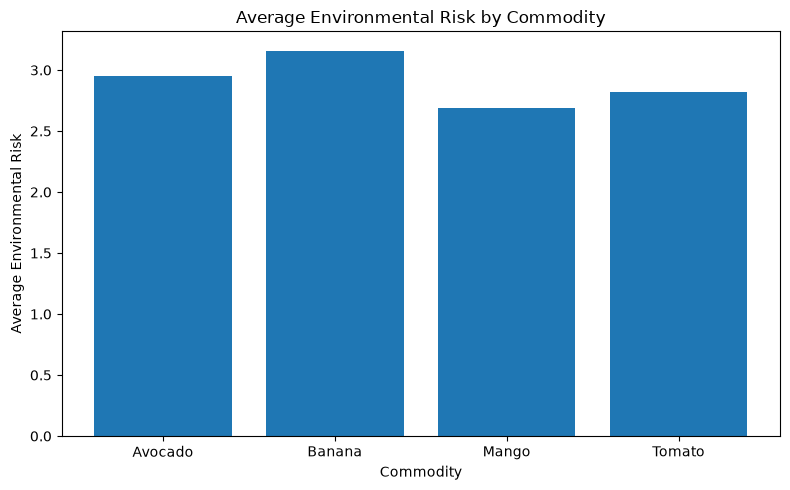

In [10]:
plt.figure(figsize=(8, 5))

plt.bar(
    commodity_summary["commodity"],
    commodity_summary["avg_environmental_risk"]
)

plt.title("Average Environmental Risk by Commodity")
plt.xlabel("Commodity")
plt.ylabel("Average Environmental Risk")

plt.tight_layout()
plt.show()

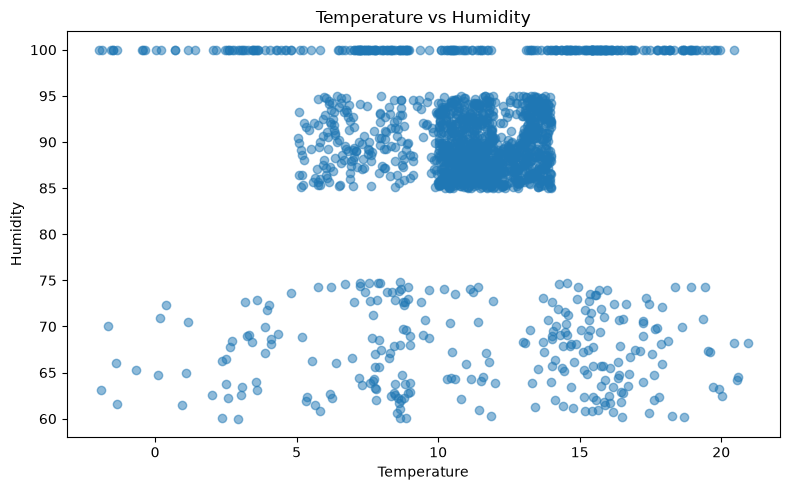

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["temperature"],
    df["humidity"],
    alpha=0.5
)

plt.title("Temperature vs Humidity")
plt.xlabel("Temperature")
plt.ylabel("Humidity")

plt.tight_layout()
plt.show()

In [12]:
print("Overall Sensor Averages:")
print(df[["temperature", "humidity", "vibration"]].mean())

print("\nHIGH/CRITICAL Risk Sensor Averages:")
high_critical = df[df["spoilage_risk"].isin(["HIGH", "CRITICAL"])]

print(
    high_critical[
        ["temperature", "humidity", "vibration"]
    ].mean()
)

Overall Sensor Averages:
temperature    11.228213
humidity       87.715496
vibration       0.191221
dtype: float64

HIGH/CRITICAL Risk Sensor Averages:
temperature    12.315097
humidity       98.391479
vibration       0.362412
dtype: float64


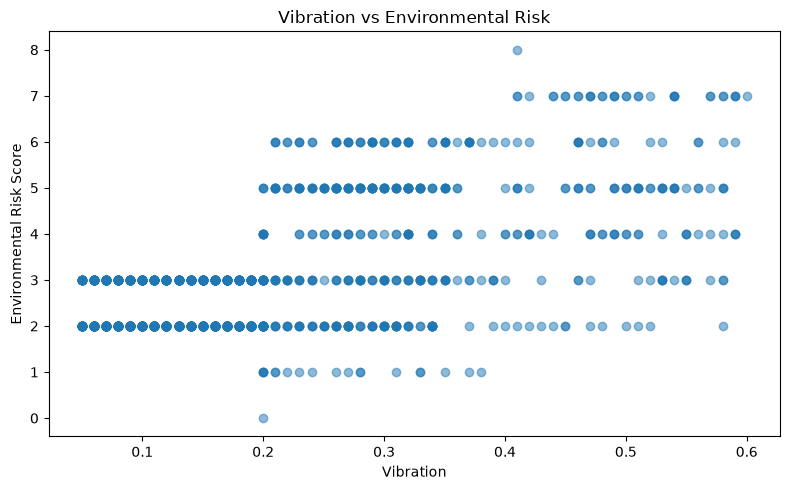

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["vibration"],
    df["environmental_risk_score"],
    alpha=0.5
)

plt.title("Vibration vs Environmental Risk")
plt.xlabel("Vibration")
plt.ylabel("Environmental Risk Score")

plt.tight_layout()
plt.show()

In [14]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df["timestamp"].min())
print(df["timestamp"].max())

2026-09-10 17:39:32.831215
2026-09-10 19:04:39.017288


In [15]:
hourly_risk = (
    df.set_index("timestamp")
      .resample("1h")["environmental_risk_score"]
      .mean()
      .reset_index()
)

print(hourly_risk.head())
print("Number of time points:", len(hourly_risk))

            timestamp  environmental_risk_score
0 2026-09-10 17:00:00                  2.878828
1 2026-09-10 18:00:00                  2.895323
2 2026-09-10 19:00:00                  3.014706
Number of time points: 3


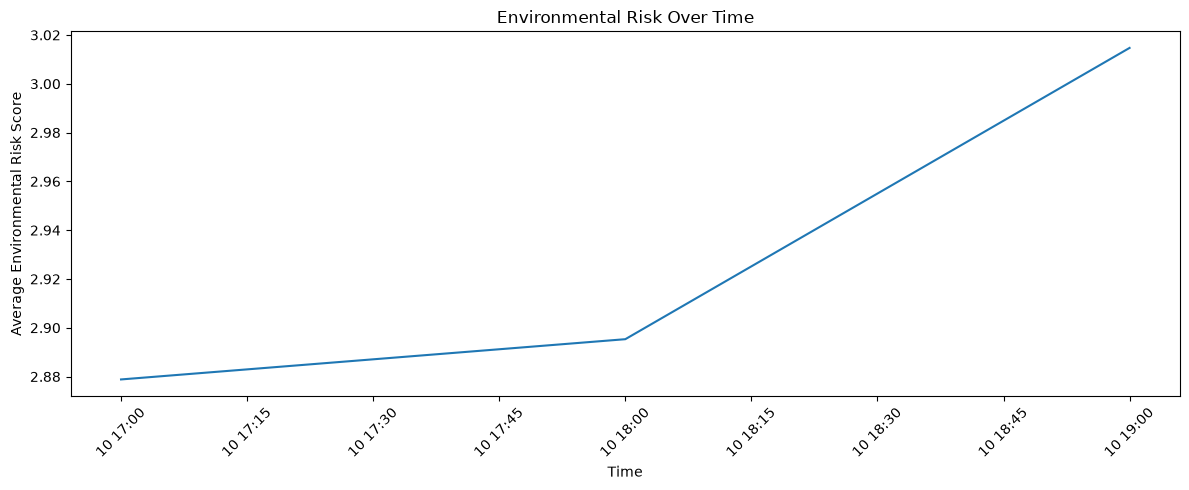

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_risk["timestamp"],
    hourly_risk["environmental_risk_score"]
)

plt.title("Environmental Risk Over Time")
plt.xlabel("Time")
plt.ylabel("Average Environmental Risk Score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
high_risk = df[
    df["spoilage_risk"].isin(["HIGH", "CRITICAL"])
].copy()

print("HIGH/CRITICAL records:", len(high_risk))

high_risk[
    [
        "container_id",
        "timestamp",
        "commodity",
        "temperature",
        "humidity",
        "vibration",
        "condition",
        "environmental_risk_score",
        "spoilage_risk"
    ]
].sort_values(
    "environmental_risk_score",
    ascending=False
).head(20)

HIGH/CRITICAL records: 257


,container_id,timestamp,commodity,temperature,humidity,vibration,condition,environmental_risk_score,spoilage_risk
511,CONT_001,2026-09-10 17:51:51.463668,Banana,20.45,100.0,0.41,ANOMALY,8,CRITICAL
1774,CONT_002,2026-09-10 19:04:18.972775,Banana,18.88,100.0,0.57,ANOMALY,7,CRITICAL
1757,CONT_005,2026-09-10 19:03:43.874639,Avocado,16.36,100.0,0.51,ANOMALY,7,CRITICAL
168,CONT_005,2026-09-10 17:42:33.281371,Avocado,18.85,100.0,0.41,ANOMALY,7,CRITICAL
1193,CONT_004,2026-09-10 18:44:24.642073,Mango,17.50,100.0,0.58,ANOMALY,7,CRITICAL
287,CONT_003,2026-09-10 17:44:33.554597,Tomato,16.06,100.0,0.49,ANOMALY,7,CRITICAL
1308,CONT_004,2026-09-10 18:48:23.573976,Avocado,18.00,100.0,0.48,ANOMALY,7,CRITICAL
1380,CONT_002,2026-09-10 18:50:48.621526,Mango,18.18,100.0,0.51,ANOMALY,7,CRITICAL
1475,CONT_003,2026-09-10 18:53:59.187633,Avocado,16.15,100.0,0.54,ANOMALY,7,CRITICAL
1265,CONT_003,2026-09-10 18:46:55.896429,Mango,18.69,100.0,0.49,ANOMALY,7,CRITICAL


In [18]:
high_risk.to_csv(
    "data/processed/high_risk_telemetry.csv",
    index=False
)

print("Saved: data/processed/high_risk_telemetry.csv")

Saved: data/processed/high_risk_telemetry.csv


In [19]:
container_summary.to_csv(
    "data/processed/container_risk_summary.csv",
    index=False
)

commodity_summary.to_csv(
    "data/processed/commodity_risk_summary.csv",
    index=False
)

print("Saved container_risk_summary.csv")
print("Saved commodity_risk_summary.csv")

Saved container_risk_summary.csv
Saved commodity_risk_summary.csv
